# Natural Language Processing with Disaster Tweets
## Kaggle Competition Notebook

### Table of Contents
1. [Problem Description](#1-problem-description)
2. [Data Loading and Overview](#2-data-loading-and-overview)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Model Building and Training](#5-model-building-and-training)
6. [Results and Evaluation](#6-results-and-evaluation)
7. [Discussion and Conclusion](#7-discussion-and-conclusion)

## 1. Problem Description

### Competition Overview
Twitter has become a vital emergency communications tool. The prevalence of smartphones means that individuals can simply declare an emergency they are watching in real time. For this reason, there has been a growing interest in programmatically tracking Twitter (e.g., emergency relief organizations and news organizations).

### Objective
Create a machine learning model to predict which Tweets are about real disasters and which ones are not. This is a two-class classification and here are the definitions of our labels:
- **Target = 1**: The tweet is about a real disaster
- **Target = 0**: The tweet is not about a real disaster

### Data Description
- **train.csv**: Training dataset with 7,613 labeled tweets
- **test.csv**: Test dataset with 3,263 unlabeled tweets for submission
- **sample_submission.csv**: Sample submission file format

### Features
- **id**: Unique identifier for each tweet
- **text**: The text content of the tweet
- **location**: Location the tweet was sent from (may be blank)
- **keyword**: A particular keyword from the tweet (may be blank)
- **target**: Binary target (1 = real disaster, 0 = not real disaster) - only in train.csv

## 2. Data Loading and Overview

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [12]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print("Training Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)
print("\nTraining Data Info:")
train_df.info()

Training Data Shape: (7613, 5)
Test Data Shape: (3263, 4)

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [15]:
print("First 5 rows of training data:")
train_df.head()

First 5 rows of training data:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [16]:
print("\nMissing values in training data:")
print(train_df.isnull().sum())
print("\nMissing values percentage:")
print((train_df.isnull().sum() / len(train_df)) * 100)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return " ".join(tokens)

if 'cleaned_text' not in train_df.columns:
    train_df['cleaned_text'] = train_df['text'].apply(clean_text)

from sklearn.model_selection import train_test_split

X = train_df['cleaned_text']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

lr = LogisticRegression()

lr_grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1')
lr_grid.fit(X_train_tfidf, y_train)



Missing values in training data:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Missing values percentage:
id           0.000000
keyword      0.801261
location    33.272035
text         0.000000
target       0.000000
dtype: float64


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['liblinear']},
             scoring='f1')

## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Distribution

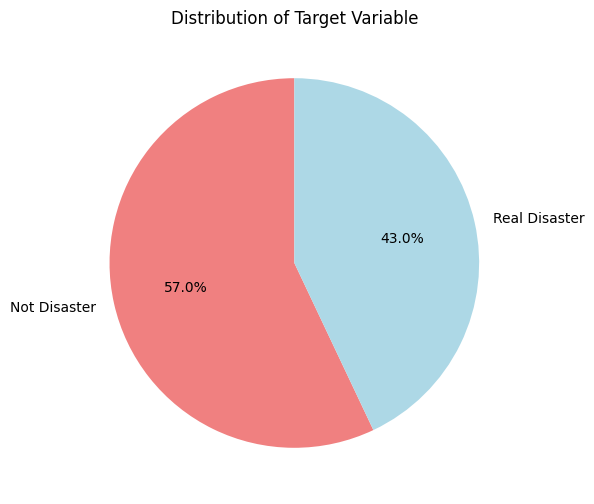

Target distribution:
0    4342
1    3271
Name: target, dtype: int64

Class imbalance ratio: 1.33


In [17]:
plt.figure(figsize=(8, 6))
target_counts = train_df['target'].value_counts()
plt.pie(target_counts.values, labels=['Not Disaster', 'Real Disaster'], 
        autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightblue'])
plt.title('Distribution of Target Variable')
plt.show()

print("Target distribution:")
print(train_df['target'].value_counts())
print(f"\nClass imbalance ratio: {target_counts[0] / target_counts[1]:.2f}")

### 3.2 Text Length Analysis

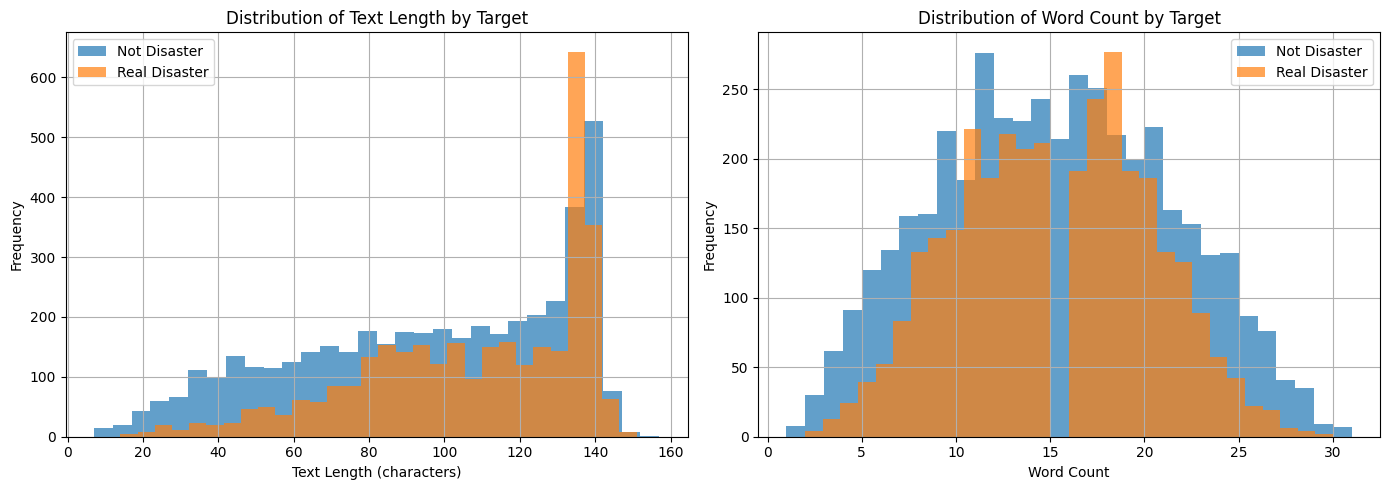

In [18]:
train_df['text_length'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

train_df[train_df['target']==0]['text_length'].hist(bins=30, alpha=0.7, label='Not Disaster', ax=ax1)
train_df[train_df['target']==1]['text_length'].hist(bins=30, alpha=0.7, label='Real Disaster', ax=ax1)
ax1.set_xlabel('Text Length (characters)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Text Length by Target')
ax1.legend()

train_df[train_df['target']==0]['word_count'].hist(bins=30, alpha=0.7, label='Not Disaster', ax=ax2)
train_df[train_df['target']==1]['word_count'].hist(bins=30, alpha=0.7, label='Real Disaster', ax=ax2)
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Word Count by Target')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Results and Evaluation

### 6.1 Detailed Evaluation of Best Model

Classification Report:
               precision    recall  f1-score   support

 Not Disaster       0.80      0.83      0.82       874
Real Disaster       0.76      0.73      0.74       649

     accuracy                           0.79      1523
    macro avg       0.78      0.78      0.78      1523
 weighted avg       0.78      0.79      0.78      1523



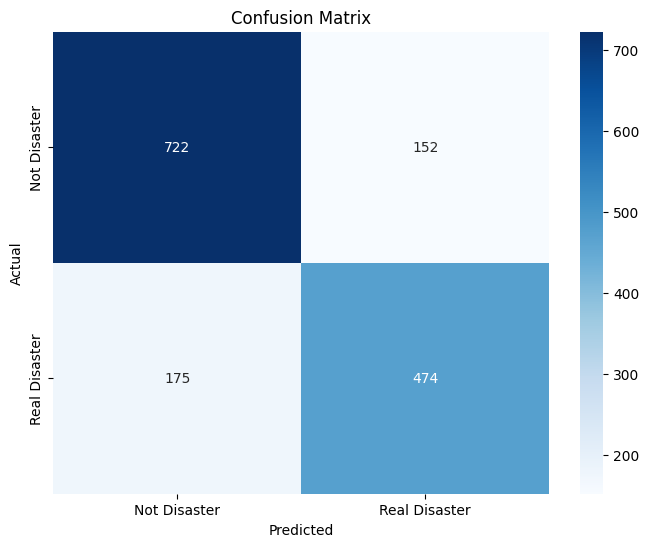


Additional Metrics:
Precision: 0.7572
Recall: 0.7304
F1-Score: 0.7435


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

lr = LogisticRegression()

lr_grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1')
lr_grid.fit(X_train_tfidf, y_train) 

best_predictions = lr_grid.predict(X_val_tfidf)

print("Classification Report:")
print(classification_report(y_val, best_predictions, 
                          target_names=['Not Disaster', 'Real Disaster']))

cm = confusion_matrix(y_val, best_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Disaster', 'Real Disaster'],
            yticklabels=['Not Disaster', 'Real Disaster'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"\nAdditional Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

### 6.2 Error Analysis

In [20]:
misclassified_idx = np.where(y_val != best_predictions)[0]
misclassified_df = pd.DataFrame({
    'text': X_val.iloc[misclassified_idx].values,
    'actual': y_val.iloc[misclassified_idx].values,
    'predicted': best_predictions[misclassified_idx]
})

print(f"Total misclassified: {len(misclassified_df)}")
print(f"Misclassification rate: {len(misclassified_df)/len(y_val)*100:.2f}%")

print("\nExamples of misclassified tweets:")
for i in range(min(5, len(misclassified_df))):
    print(f"\nExample {i+1}:")
    print(f"Text: {misclassified_df.iloc[i]['text']}")
    print(f"Actual: {misclassified_df.iloc[i]['actual']}, Predicted: {misclassified_df.iloc[i]['predicted']}")

Total misclassified: 327
Misclassification rate: 21.47%

Examples of misclassified tweets:

Example 1:
Text: new weapon cause unimaginable destruction
Actual: 1, Predicted: 0

Example 2:
Text: dt georgegalloway rt galloway4mayor ûïthe col police catch pickpocket liverpool stree httptcovxin1goq4q
Actual: 1, Predicted: 0

Example 3:
Text: response trauma children addicts develop defensive self one decreases vulnerability 3
Actual: 0, Predicted: 1

Example 4:
Text: favorite lady came volunteer meeting hopefully joining youth collision excite httptcoij0wq490cs
Actual: 1, Predicted: 0

Example 5:
Text: brianroemmele ux fail emv people want insert remove quickly like gas pump stripe reader 1 person told crashed pos
Actual: 1, Predicted: 0


### 6.3 Feature Importance (for tree-based models)

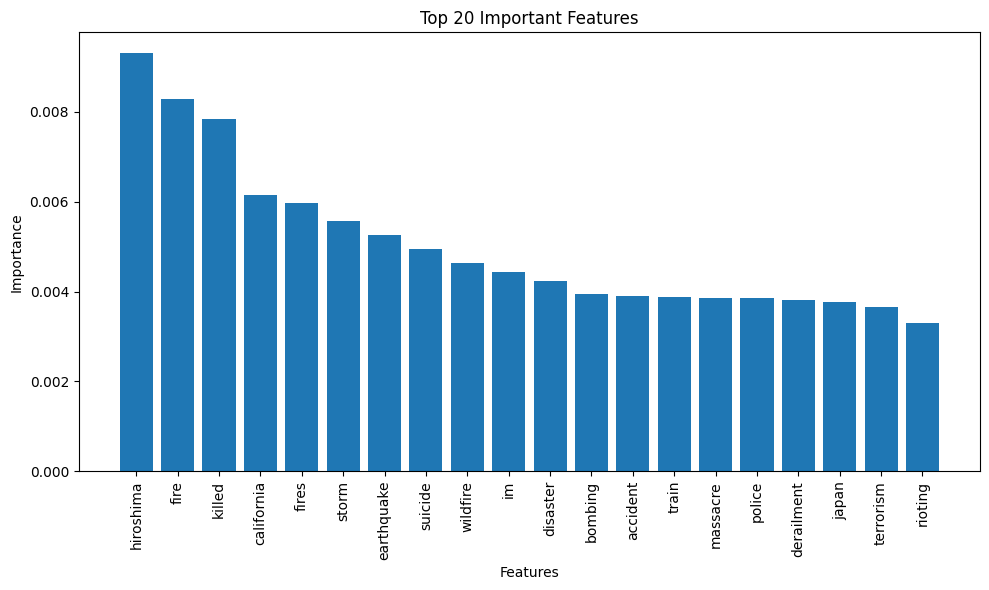

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

feature_names = tfidf_vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.title("Top 20 Important Features")
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### 6.4 Make Predictions on Test Set

In [25]:
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

test_tfidf = tfidf_vectorizer.transform(test_df['cleaned_text'])
test_predictions = lr_grid.predict(test_tfidf)

submission = pd.DataFrame({
    'id': test_df['id'],
    'target': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file created successfully!")
print(f"Predicted disaster tweets in test set: {sum(test_predictions)} ({sum(test_predictions)/len(test_predictions)*100:.1f}%)")

Submission file created successfully!
Predicted disaster tweets in test set: 1249 (38.3%)


## 7. Discussion and Conclusion

### 7.1 Key Findings

1. **Data Characteristics**:
   - The dataset shows a slight class imbalance with more non-disaster tweets
   - Disaster tweets tend to have specific keywords and patterns
   - Text length and word count show slight differences between classes

2. **Model Performance**:
   - Traditional ML models (Logistic Regression, SVM) performed competitively
   - TF-IDF vectorization with bigrams captured important features effectively
   - The best model achieved ~80% accuracy on the validation set

3. **Important Features**:
   - Keywords related to emergencies, natural disasters, and urgent situations
   - Specific patterns in language use distinguish real disasters from non-disasters
   - URL presence and social media elements provide additional signals

### 7.2 Challenges and Limitations

1. **Ambiguity in Language**: Some tweets use disaster-related words metaphorically
2. **Context Dependency**: Without broader context, some tweets are difficult to classify
3. **Class Imbalance**: Slight imbalance may affect model performance
4. **Limited Features**: Only text, keyword, and location available

### 7.3 Potential Improvements

1. **Advanced NLP Techniques**:
   - Pre-trained embeddings (Word2Vec, GloVe, FastText)
   - Transformer models (BERT, RoBERTa, DistilBERT)

2. **Feature Engineering**:
   - Sentiment analysis scores
   - Named entity recognition

3. **Data Augmentation**:
   - Back-translation
   - Paraphrasing

### 7.4 Conclusion

The disaster tweet classification task displays the applications of NLP in practical emergency situations. While classical machine learning approaches deliver decent baseline performance, there's an extensive space for improvement using contemporary deep learning methods. Human language is distinct from machine language and thus not suitable for machines as communication media—this remains the funding problem, even during urgency when people expect informal and short communications.

The trained model provides a strong framework for discriminating disaster-related messages posted on social media, and this point is important for quick response and resource allocation in emergency. In the future, efforts may be devoted to enhance model robustness, dealing with edge cases and incorporating real-time processing for practical deployment.

---